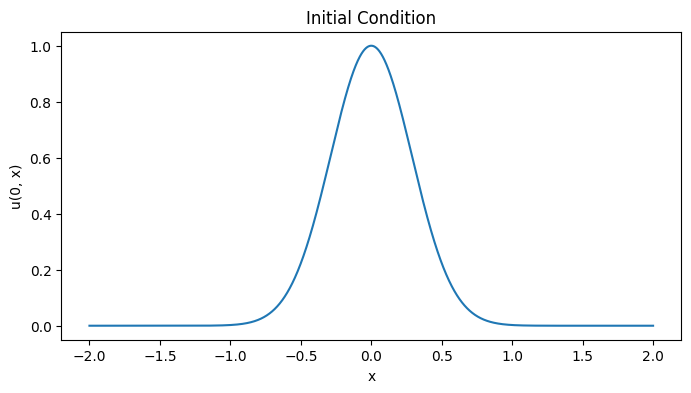

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Parameters
a, b = -2, 2
dx = 0.002
dt = 0.001
c = 1
T_e = 2

# Grid
x = np.arange(a, b + dx, dx)
u = np.exp(-6 * x**2)

t = dt

plt.figure(figsize=(8, 4))
plt.plot(x, u)
plt.title("Initial Condition")
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.show()


In [2]:
save_times = [0.5, 1.0, 1.5, 2.0]
saved_solutions = {}

start = time.time()

while t <= T_e:
    v = np.empty_like(u)

    # interior points
    v[1:-1] = u[1:-1] - c * dt/dx * (u[1:-1] - u[:-2])

    # first element
    v[0] = u[0] - c * dt/dx * (u[0] - u[-1])

    # last element
    v[-1] = u[-1] - c * dt/dx * (u[-1] - u[-2])

    u = v

    for ts in save_times:
        if abs(t - ts) < dt/2:
            saved_solutions[ts] = u.copy()

    t += dt

end = time.time()
print("Runtime (vectorized):", end - start)


Runtime (vectorized): 0.009113073348999023


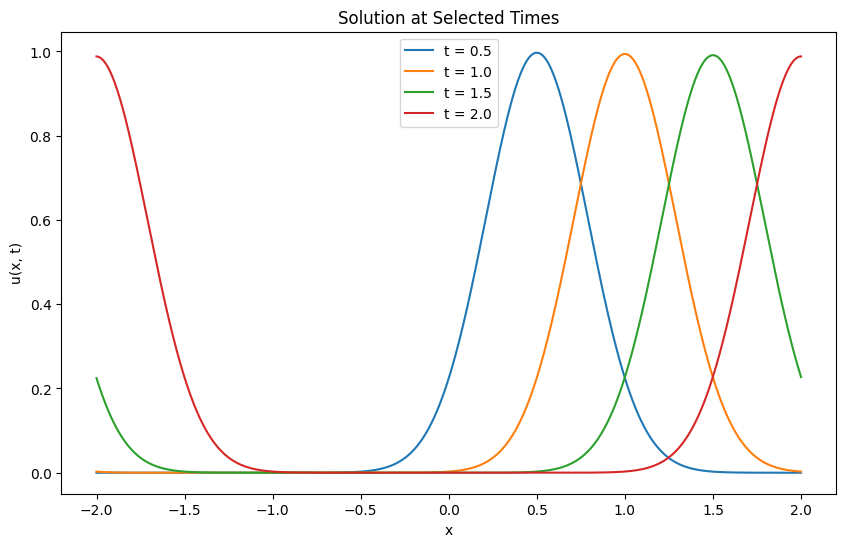

In [3]:
plt.figure(figsize=(10, 6))
for ts in save_times:
    if ts in saved_solutions:
        plt.plot(x, saved_solutions[ts], label=f"t = {ts}")

plt.title("Solution at Selected Times")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.show()

In [4]:
import numpy as np
import time
a, b = -2, 2
dx = 0.002
dt = 0.001
c = 1
T_e = 2

x = np.arange(a, b, dx)
u = np.exp(-6 * x**2)

start = time.time()

t = 0
while t <= T_e:

    u_shift = np.roll(u, 1)
    
    u = u - c * dt/dx * (u - u_shift)
    
    t += dt

end = time.time()
print("runtime:", end - start)

runtime: 0.013668060302734375
